# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
import numpy as np

def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  # element wise sum of X1 and X2

  result = [a + b for a, b in zip(X1, X2)]
  state_neuron = []
  for i in result:
    if i >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    result = [a + b for a, b in zip(X1, X2)]
    state_neuron = []
    for i in result:
      if i >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# 3.2.1 Answer the Following Question:
• Question - 1: List out all the limitations of MCP - Neurons.
-> Here are all the limitations of McCulloh-Pitts(MCP) Neurons:
  1. Only binary input can be provided(0 or 1).
  2. It uses a hard threshold(sum >= threshold then 1 or 0) which is non-differentiable.
  3. It cannot learn from data, weights must be manually saved.
  4. It cannot work for non-linearly seperated data (OR and AND) not XOR.
  5. It's a single layer network and cannot model complex patterns or        hierarchical relationships.
  6. No Capability for Feature Extraction
  

• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
-> Since XOR basically is a true condition where either of the input is true(1).
  We can think of solving it through the combination of if else logic.
  Since MCP uses inequality operators(logically), we can write the if else logic to solve XOR problem like:

    if (x1 + x2 >= 1 AND x1 + x2 < 2)
      XOR = 1
    else
      XOR = 0

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI-ML/Data/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


# Answer the Following Question:

1. Question - 1: What does the shape of X represent?

-> It means there are 12665 number of samples with 784 number of features per sample.


2. Question - 2: What does the shape of Y represent?

-> It means their are 12665 numbers of target samples

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Viewing the Dataset.

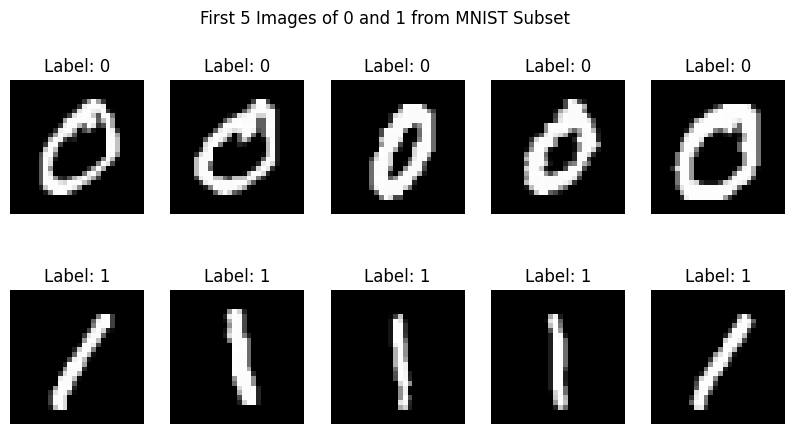

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

# Answer the Following Question:
1. Question - 3: What does the weights array represent in this context?

-> The weights array represent the weights that are going to be used with      each of the neurons of the input layer since there are 784 features (or input layer) to be used in this neural network.  


2. Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

-> We initialize the weights to zero as a starting point before training begins. However, initializing all weights to zero can be problematic because all neurons will learn the same features during training, leading to no meaningful learning. Therefore, weights are usually initialized with small random values instead.

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        for i in range(len(X)):
          z = np.dot(X[i], weights) + bias
          y_hat = 1 if z >= 0 else 0

          if y_hat != y[i]:
            weights += learning_rate * (y[i] - y_hat) * X[i]
            bias += learning_rate * (y[i] - y_hat)

    # calculating the accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    print("Accuracy: ", accuracy)


    return weights, bias, accuracy

# Answer the Following Question:
1. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

-> This is the main functionality of each neuron where each neurons calculates the dot product of its connected features, weights and add bias to it to further pass the to activation function.

2. Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?

-> When a prediction is wrong, it is firstly detected using loss function, then following steps are implemented:
1. partial derivative of loss function with respect to each weight is calculated
2. chain rule is used to do such calculations as the weights are never directly related to loss function.
3. then finally, each weight is updated by the difference of that weight to learning rate times the previous derivative relation.

3. Question - 7:Why is the final accuracy important, and what do you expect it to be?

-> The final accuracy is important in terms of judging how good the model we created is, it helps us determine things like:
1. if the model learnt from the data well
2. if we need more training data
3. if we need more epochs

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Accuracy:  0.9984208448480063
The Final Accuracy is:  0.9984208448480063


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9974


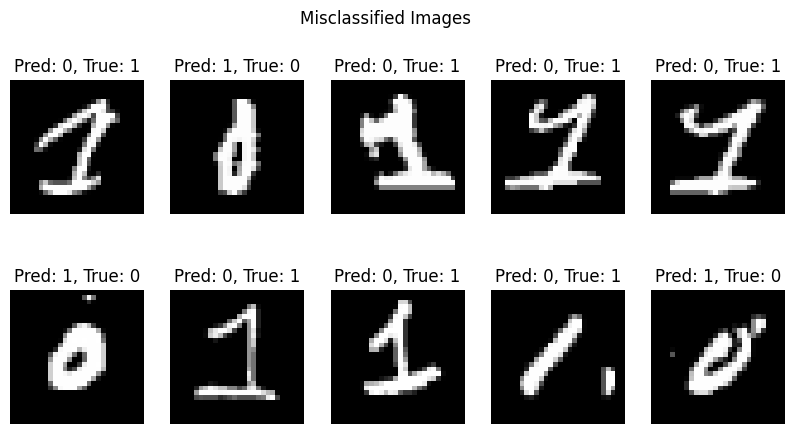

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

# Answer the Following Question:

1. Question - 8:What does misclassified idx store, and how is it used in this code?

-> Misclassified idx is a variable we created with all the predicted output    that equal to real output.
  misclassified_idx = np.where(y_pred != y)[0]

  We have used it in code to visualize the wrongly predicted images with and compare what the real predicted value should be.

2. Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?

-> If the result was ”All images were correctly classified!”, we can interpret following things.

1. The model may have been overfitted.
2. The model learnt enough to classify all the instances of 0 and 1 correctly.

# 4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI-ML/Data/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values  # Labels (3 or 5)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


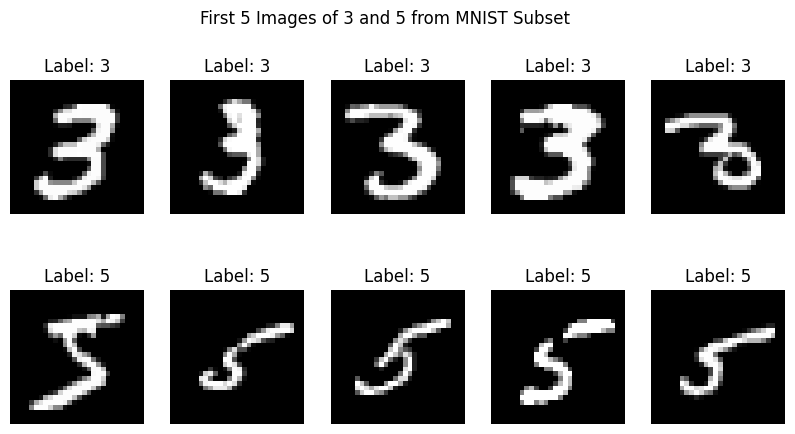

In [ ]:
# Separate images for label 0 and label 1
images_3 = X[y == 3]  # Get all images with label 0
images_5 = X[y == 5]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 5, 3)

    return y_pred_all

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        for i in range(len(X)):
          z = np.dot(X[i], weights) + bias
          y_hat = 1 if z >= 0 else -1

          if y_hat != y[i]:
            weights += learning_rate * (y[i] - y_hat) * X[i]
            bias += learning_rate * (y[i] - y_hat)

    # calculating the accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)
    print("Accuracy: ", accuracy)


    return weights, bias, accuracy

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Accuracy:  0.45859175483400216
The Final Accuracy is:  0.45859175483400216


Final Accuracy: 0.4586


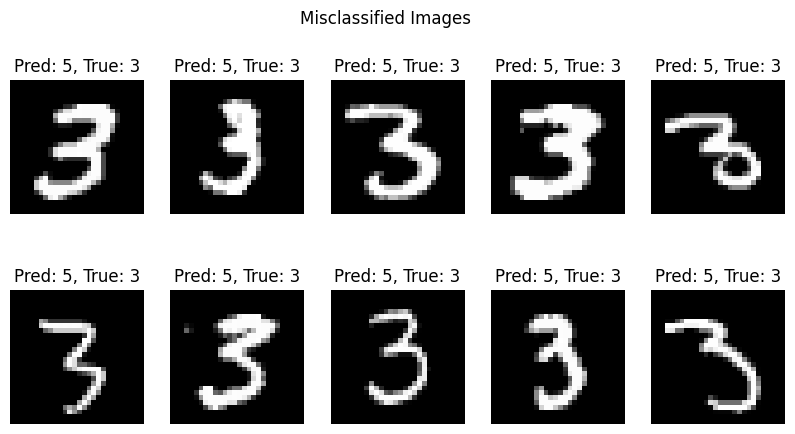

In [ ]:
  # Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 3, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 3:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")